In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from anjana.anonymity import (
    k_anonymity_inner,
    k_anonymity,
    l_diversity,
    t_closeness,
    alpha_k_anonymity,
)
from masking_effects_on_xai_techniques import finding_k
from masking_effects_on_xai_techniques import anonymized_preprocessor as anon_prep
import masking_effects_on_xai_techniques.hierarchies as hi

# Preprocessing

In [2]:
path = "../data/usa_house/"

In [3]:
df = pd.read_csv(path + "data.csv")
len_data = len(df)

# Clean the data
df.dropna(inplace=True)
df = df.drop("Address", axis=1)

len_clean_data = len(df)
print(f"Dropped {len_data - len_clean_data} rows")

Dropped 0 rows


In [4]:
df["Price"]

0       1.059034e+06
1       1.505891e+06
2       1.058988e+06
3       1.260617e+06
4       6.309435e+05
            ...     
4995    1.060194e+06
4996    1.482618e+06
4997    1.030730e+06
4998    1.198657e+06
4999    1.298950e+06
Name: Price, Length: 5000, dtype: float64

In [5]:
# df['Price'] = pd.cut(df['Price'], bins=8, include_lowest=True)

In [6]:
df["Price"] = pd.qcut(df["Price"], 8)

In [7]:
le = LabelEncoder()

df["Price"] = le.fit_transform(df["Price"])

for i, class_label in enumerate(le.classes_):
    print(f"Original: {class_label} -> Encoded: {i}")

Original: (15938.657, 821575.761] -> Encoded: 0
Original: (821575.761, 997577.135] -> Encoded: 1
Original: (997577.135, 1116838.041] -> Encoded: 2
Original: (1116838.041, 1232669.378] -> Encoded: 3
Original: (1232669.378, 1350664.588] -> Encoded: 4
Original: (1350664.588, 1471210.204] -> Encoded: 5
Original: (1471210.204, 1637832.57] -> Encoded: 6
Original: (1637832.57, 2469065.594] -> Encoded: 7


# Hiearchies

In [8]:
df.nunique()

Avg. Area Income                5000
Avg. Area House Age             5000
Avg. Area Number of Rooms       5000
Avg. Area Number of Bedrooms     255
Area Population                 5000
Price                              8
dtype: int64

All features are continous numbers, except the Avg. Area Number of Bedrooms. Therefore we set level of bins at 50 for all features except that single one. We set that at 5. Then there are approxmiately 50 elements in the first level

In [9]:
df.columns

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price'],
      dtype='object')

In [10]:
hierarchies_path = "../hierarchies/usa_house"


def create_and_save(feat, n):
    hierarchies[feat] = hi.generate_qcut_hierarchy(df[feat], n)
    hi.save_hierarchy(hierarchies[feat], f"{hierarchies_path}/{feat}.csv")


categories = df.columns.to_list()
bedroom = "Avg. Area Number of Bedrooms"
categories.remove(bedroom)

hierarchies = dict()
for cat in categories:
    create_and_save(cat, 3)
    hierarchies[cat] = dict(
        pd.read_csv(f"../hierarchies/usa_house/{cat}.csv", header=None)
    )

create_and_save(bedroom, 3)
hierarchies[bedroom] = dict(
    pd.read_csv(f"../hierarchies/usa_house/{bedroom}.csv", header=None)
)

# Anonymization

In [11]:
ident = []
sens_att = "Price"
quasi_ident = list(df.columns)
quasi_ident.remove(sens_att)

In [12]:
all_counts_and_features = []
for feat, items in hierarchies.items():
    for item in items.values():
        length = len(item.unique())
        all_counts_and_features.append((length, feat))
sorted_data = sorted(all_counts_and_features, key=lambda x: x[0], reverse=True)
ordered_features = [feat for count, feat in sorted_data]

for feat, items in hierarchies.items():
    lengths = [f"{len(item.unique()):>4}" for item in items.values()]
    out = ", ".join(lengths)
    print(f"{feat:<15}: {out}")

print("Order in which features will be generalized:")
print(ordered_features)

Avg. Area Income: 5000,    3,    2,    1
Avg. Area House Age: 5000,    3,    2,    1
Avg. Area Number of Rooms: 5000,    3,    2,    1
Area Population: 5000,    3,    2,    1
Price          :    8,    3,    2,    1
Avg. Area Number of Bedrooms:  255,    3,    2,    1
Order in which features will be generalized:
['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Area Population', 'Avg. Area Number of Bedrooms', 'Price', 'Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Area Population', 'Price', 'Avg. Area Number of Bedrooms', 'Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Area Population', 'Price', 'Avg. Area Number of Bedrooms', 'Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Area Population', 'Price', 'Avg. Area Number of Bedrooms']


In [13]:
%%time
k = 10
supp_level = 20
anon_df, supp_n, hiear = k_anonymity_inner(
    df, ident, quasi_ident, k, supp_level, hierarchies
)
max_supp_n = int(round(len(df) * supp_level / 100, 0))
print(f"Max rows that can be suppressed: {max_supp_n}")
print(f"Rows suppressed                : {supp_n}")
print(f"% of allowed rows suppressed   : {round(supp_n / max_supp_n * 100, 1)}%")
print(f"Generalization level           : {sum(hiear.values())}")
hiear

Max rows that can be suppressed: 1000
Rows suppressed                : 222
% of allowed rows suppressed   : 22.2%
Generalization level           : 5
CPU times: user 1.32 s, sys: 188 ms, total: 1.51 s
Wall time: 1.51 s


{'Avg. Area Income': 1,
 'Avg. Area House Age': 1,
 'Avg. Area Number of Rooms': 1,
 'Avg. Area Number of Bedrooms': 1,
 'Area Population': 1}

In [14]:
# k_list = [2, 4, 6, 8, 9, 10, 11, 12]
anon_data = finding_k.generate_k_anonymity_data(
    df,
    20,
    ident,
    quasi_ident,
    hierarchies,  # , k_list
)

Anonymizing for k=2
Anonymizing for k=4
Anonymizing for k=8
Anonymizing for k=16
Anonymizing for k=32
Anonymizing for k=64
Anonymizing for k=128
Anonymizing for k=256
Done anonymizing


In [15]:
models, scores = finding_k.train_models(anon_data, "Price", hierarchies_path)

/home/kochc/projects/bachelor/Masking-Effects-on-XAI-Techniques/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


0.3515


/home/kochc/projects/bachelor/Masking-Effects-on-XAI-Techniques/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


0.3483709273182957
0.361439588688946


/home/kochc/projects/bachelor/Masking-Effects-on-XAI-Techniques/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


0.3611594202898551


/home/kochc/projects/bachelor/Masking-Effects-on-XAI-Techniques/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


0.28125
0.26867469879518074
0.2094130089899524
0.1959140911471975


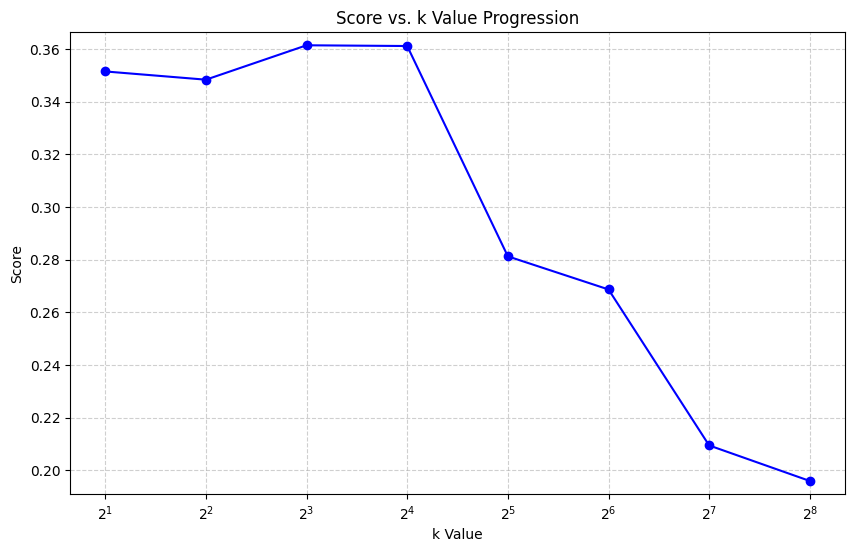

In [16]:
finding_k.plot_k_vs_score(scores)  # , k_list)

In [17]:
df.to_csv(path + "clean.csv", index=False)